### Genetic Algorithm
- We don't calculate the optimal solution directly. 
- Instead, we start by randomly generating many potential solutions. 
- then continuously keep the good ones, combine the successful traits. 
- occasionally introduce random mutations.
- finally converge on the optimal solution.

### What kind of problems are Genetic Algorithms suitable for?

Genetic Algorithms are particularly suitable for:

* Functions that are very complex and difficult to derive (calculate gradients).
* Objective functions that are discontinuous.
* Large search spaces.
* Problems with many local optima.
* Combinatorial optimization problems.

**Examples:**

* Parameter optimization.
* Path planning.
* Feature selection.
* Neural network hyperparameter optimization.
* Scheduling problems.
* TSP (Traveling Salesman Problem).

### Basic Workflow of Genetic Algorithms

The standard steps for a Genetic Algorithm are:

1.  **Initialize Population:** Create a starting set of potential solutions.
2.  **Calculate Fitness:** Evaluate how "good" each individual solution is.
3.  **Select Elite Individuals:** Choose the best performing solutions to be parents.
4.  **Crossover:** Combine traits from parents to produce offspring.
5.  **Mutation:** Randomly alter some traits to increase diversity.
6.  **Form New Generation:** Replace the old population with the new offspring.
7.  **Repeat:** Continue the process until the stopping criteria are met.

### Problem Definition
**Goal:**
$$\max f(x) = x^2, \quad x \in [0, 31]$$

In [56]:
import random
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. 基本参数
# =========================
POP_SIZE = 3          # 种群大小
CHROM_LENGTH = 5      # 染色体长度（5位二进制，可表示0~31）
CROSS_RATE = 0.8      # 交叉概率
MUTATION_RATE = 0.1   # 变异概率
GENERATIONS = 5      # 迭代代数
LOW, HIGH = 0, 31

In [20]:
# =========================
# 2. 编码与解码
# =========================
def binary_to_decimal(chromosome):
    """把二进制列表转成十进制整数"""
    return int("".join(map(str, chromosome)), 2)

def decimal_to_binary(x, length=5):
    """把十进制转成固定长度二进制列表"""
    return list(map(int, format(x, f'0{length}b')))

In [37]:
chromosome = [1, 0, 1, 0, 1]
x = binary_to_decimal(chromosome)

print("chromosome =", chromosome)
print("decimal =", x)

chromosome = [1, 0, 1, 0, 1]
decimal = 21


In [38]:
x = 13
chromosome = decimal_to_binary(x)

print("x =", x)
print("binary chromosome =", chromosome)

x = 13
binary chromosome = [0, 1, 1, 0, 1]


In [21]:
# =========================
# 3. 目标函数 / 适应度函数
# =========================
def objective_function(x):
    return x ** 2

def fitness(chromosome):
    x = binary_to_decimal(chromosome)
    return objective_function(x)

In [39]:
chromosome = [1, 0, 1, 0, 0]   # 二进制 10100 = 十进制 20
fit = fitness(chromosome)

print("chromosome =", chromosome)
print("x =", binary_to_decimal(chromosome))
print("fitness =", fit)

chromosome = [1, 0, 1, 0, 0]
x = 20
fitness = 400


In [22]:
# =========================
# 4. 初始化种群
# =========================
def init_population(pop_size, chrom_length):
    """
    pop_size: 种群大小（包含多少个个体）
    chrom_length: 染色体长度（每个个体有多少个基因）
    """
    population = []  
    
     # 循环创建每个个体，直到达到种群大小
    for individual_index in range(pop_size):
        # 为当前个体创建染色体：一个由0和1组成的列表
        chromosome = []

        for gene_position in range(chrom_length):
            # 随机生成0或1作为基因值
            gene = random.randint(0, 1)
            # 将基因添加到染色体中
            chromosome.append(gene)
        
        population.append(chromosome)
    
    return population

In [40]:
population = init_population(4, 5)
print(population)

[[0, 0, 0, 0, 1], [1, 0, 0, 0, 0], [1, 1, 1, 1, 0], [1, 0, 1, 1, 0]]


### Output Interpretation

**This represents:**

* A total of **4 individuals**.
* Each individual has **5 gene loci** (bits).
* Each locus can only be **0 or 1**.

This is the **initial "candidate solution set"** of the Genetic Algorithm.

---

### Selection(population)

**Function:**
Selects an individual from the population to serve as a parent, based on their fitness probability.

**The method used here is Roulette Wheel Selection:**
$$p_i = \frac{f_i}{\sum_j f_j}$$

The **higher the fitness**, the **greater the probability** of being selected.

In [ ]:
# =========================
# 5. 轮盘赌选择
# =========================
def selection(population):
    """
    从种群中选择一个个体（基于适应度的轮盘赌选择）
    
    参数:
        population: 种群列表，每个元素是一个个体的染色体
    
    返回:
        被选中的个体（副本）
    """
    
    # 步骤1: 计算每个个体的适应度
    # -----------------------------------------------------------------
    # 对种群中的每个个体调用fitness()函数，得到适应度值
    fitness_values = []
    for individual in population:
        # 计算当前个体的适应度
        fit_value = fitness(individual)
        fitness_values.append(fit_value)
    
    # 转换为NumPy数组以便进行数值计算
    fitness_values = np.array(fitness_values, dtype=float)
    
    # 步骤2: 计算选择概率（适应度比例法）
    # -----------------------------------------------------------------
    total_fitness = fitness_values.sum()  # 计算所有个体适应度之和
    
    # 处理特殊情况：如果所有个体的适应度之和为0
    if total_fitness == 0:
        # 所有个体被选中的概率相等（随机选择）
        probabilities = np.ones(len(population)) / len(population)
        print("警告：所有个体适应度为0，采用均匀随机选择")
    else:
        # 正常情况：每个个体的选择概率与其适应度成正比
        probabilities = fitness_values / total_fitness
    
    
    # 步骤3: 根据概率随机选择一个个体
    # -----------------------------------------------------------------
    # 确定要选择的个体索引
    # np.random.choice 会根据指定的概率随机选择一个索引
    population_size = len(population)
    selected_index = np.random.choice(
        population_size,      # 从0到population_size-1中选择
        p=probabilities       # 每个索引被选中的概率
    )
    
    # 获取被选中的个体
    selected_individual = population[selected_index]

    individual_copy = selected_individual[:]

    return individual_copy

In [41]:
population = [
    [0,0,1,1,1],   # 7   -> 49
    [0,1,1,0,1],   # 13  -> 169
    [1,0,1,0,0],   # 20  -> 400
    [1,1,0,0,0]    # 24  -> 576
]

chosen = selection(population)

print("population =", population)
print("chosen parent =", chosen)

population = [[0, 0, 1, 1, 1], [0, 1, 1, 0, 1], [1, 0, 1, 0, 0], [1, 1, 0, 0, 0]]
chosen parent = [1, 1, 0, 0, 0]


### Crossover(parent1, parent2, cross_rate=0.8)

**Function:**
Allows two parents to cross over to generate two offspring.

**The idea of crossover is:**
* Take the **first half** of Parent 1.
* Take the **second half** of Parent 2.
* **Combine them** to obtain a new individual.

This is called **Single-Point Crossover**.

In [ ]:
# =========================
# 6. 单点交叉
# =========================
def crossover(parent1, parent2, cross_rate=0.8):
    """
    对两个父代个体进行交叉操作（单点交叉）
    
    参数:
        parent1: 第一个父代个体（染色体列表）
        parent2: 第二个父代个体（染色体列表）
        cross_rate: 交叉概率，决定是否进行交叉操作
    
    返回:
        child1, child2: 两个子代个体
    """
    
    # 步骤1: 先创建父代的副本作为子代的初始值
    # -------------------------------------------------
    # 这样做是为了当不发生交叉时，直接返回父代的副本
    child1 = parent1[:]  # 创建parent1的副本
    child2 = parent2[:]  # 创建parent2的副本
    
    # 步骤2: 根据交叉概率决定是否进行交叉
    # random.random() 生成一个[0,1)之间的随机数
    # 如果这个随机数小于交叉概率，就执行交叉
    if random.random() < cross_rate:
        
        # 步骤3: 随机选择交叉点
        # -------------------------------------------------
        # 交叉点必须在[1]到[染色体长度-1]之间
        # 例如: 染色体长度=10, 交叉点可以是1-9,这样确保每个子代至少从每个父代获得一个基因
        chromosome_length = len(parent1)
        crossover_point = random.randint(1, chromosome_length - 1)
        
        print(f"执行交叉: 交叉点位置 = {crossover_point}")  # 调试信息
        
        # 步骤4: 执行单点交叉
        # -------------------------------------------------
        # 子代1: 取父代1的前半部分 + 父代2的后半部分
        # 子代2: 取父代2的前半部分 + 父代1的后半部分
        child1 = parent1[:crossover_point] + parent2[crossover_point:]
        child2 = parent2[:crossover_point] + parent1[crossover_point:]
        
        # 可以打印交叉过程（调试用）
        print(f"父代1: {parent1}")
        print(f"父代2: {parent2}")
        print(f"子代1: {child1}")
        print(f"子代2: {child2}")
    else:
        print(f"不执行交叉，直接复制父代")  # 调试信息
    
    # 步骤5: 返回两个子代
    return child1, child2

In [45]:
parent1 = [1, 0, 1, 0, 0]
parent2 = [1, 1, 0, 0, 0]

child1, child2 = crossover(parent1, parent2, cross_rate=1.0) # cross_rate=1.0 表示一定交叉。

print("parent1 =", parent1)
print("parent2 =", parent2)
print("child1  =", child1)
print("child2  =", child2)

执行交叉: 交叉点位置 = 2
parent1 = [1, 0, 1, 0, 0]
parent2 = [1, 1, 0, 0, 0]
child1  = [1, 0, 0, 0, 0]
child2  = [1, 1, 1, 0, 0]


In [49]:
# =========================
# 7. 变异
# =========================
def mutate(chromosome, mutation_rate=0.1):
    """
    对染色体进行变异操作（位翻转变异）

    参数:
        chromosome: 原始染色体（由0和1组成的列表）
        mutation_rate: 变异率，每个基因发生变异的概率
    
    返回:
        new_chromosome: 变异后的新染色体
    """
    
    # 步骤1: 创建原始染色体的副本
    # -------------------------------------------------
    # 为什么要创建副本？因为我们要保留原始染色体不变，
    # 只在副本上进行修改，然后返回新的染色体
    new_chromosome = chromosome[:]  # [:] 是创建列表的副本
    
    # 步骤2: 遍历染色体上的每个基因位置
    # -------------------------------------------------
    # 对每个基因，根据变异率决定是否要翻转它
    number_of_genes = len(new_chromosome)
    
    print(f"变异数量：{number_of_genes}")

    for gene_position in range(number_of_genes):
        
        # 步骤3: 生成随机数决定当前基因是否变异
        # -------------------------------------------------
        # random.random() 生成一个[0,1)之间的随机数
        # 如果这个随机数小于变异率，就执行变异
        random_value = random.random()
        
        if random_value < mutation_rate:
            # 步骤4: 执行变异 - 翻转基因（0变1，1变0）
            # -------------------------------------------------
            current_gene = new_chromosome[gene_position]
            
            print(f"变异点位置 = {gene_position}")  # 调试信息

            # 方法1: 使用 1 - current_gene 来翻转
            # 如果当前是0，1-0=1；如果当前是1，1-1=0
            new_gene = 1 - current_gene
            
            # 更新基因值
            new_chromosome[gene_position] = new_gene
            
            # 可选：打印变异信息（调试用）
            print(f"位置 {gene_position}: {current_gene} -> {new_gene}")
    
    # 步骤5: 返回变异后的新染色体
    return new_chromosome

In [51]:
chromosome = [1, 0, 1, 0, 0]
new_chromosome = mutate(chromosome, mutation_rate=0.5)

print("before =", chromosome)
print("after  =", new_chromosome)

变异数量：5
变异点位置 = 0
位置 0: 1 -> 0
变异点位置 = 1
位置 1: 0 -> 1
before = [1, 0, 1, 0, 0]
after  = [0, 1, 1, 0, 0]


In [26]:
# =========================
# 8. 找最优个体
# =========================
def best_individual(population):
    best = population[0]
    best_fit = fitness(best)

    for ch in population[1:]:
        fit = fitness(ch)
        if fit > best_fit:
            best = ch
            best_fit = fit

    return best, best_fit

In [52]:
population = [
    [0,0,1,1,1],   # 7  -> 49
    [0,1,1,0,1],   # 13 -> 169
    [1,0,1,0,0],   # 20 -> 400
    [1,1,0,0,0]    # 24 -> 576
]

best_ch, best_fit = best_individual(population)

print("best chromosome =", best_ch)
print("best x =", binary_to_decimal(best_ch))
print("best fitness =", best_fit)

best chromosome = [1, 1, 0, 0, 0]
best x = 24
best fitness = 576


In [60]:
# =========================
# 9. 主循环
# =========================
population = init_population(POP_SIZE, CHROM_LENGTH)

print(f"population = {population}")

best_fitness_history = []
best_x_history = []

# ========== 遗传算法主循环 ==========
# 对每一代进行迭代
for generation in range(GENERATIONS):
    
    # ========== 步骤1: 找出当前代的最优个体 ==========
    # best_individual() 函数返回当前种群中适应度最高的个体
    # best_ch: 最优个体的染色体
    # best_fit: 最优个体的适应度值
    best_ch, best_fit = best_individual(population)
    
    # 将二进制染色体转换为十进制数值（用于显示和理解）
    best_x = binary_to_decimal(best_ch)
    
    # ========== 步骤2: 记录历史数据 ==========
    best_fitness_history.append(best_fit)  # 记录最优适应度
    best_x_history.append(best_x)           # 记录最优x值

    print(f"第 {generation:02d} 代: "
          f"best chromosome = {best_ch}, "
          f"x = {best_x}, "
          f"fitness = {best_fit}")
    
    # ========== 步骤4: 精英保留策略 ==========
    new_population = [best_ch[:]]  # 创建最优个体的副本
    
    # ========== 步骤5: 生成新一代种群 ==========
    while len(new_population) < POP_SIZE:
        
        # 5.1 选择两个父代个体
        # 使用轮盘赌选择法，根据适应度选择优秀个体
        parent1 = selection(population)  # 选择第一个父代
        parent2 = selection(population)  # 选择第二个父代
        
        # 5.2 交叉操作
        # 以 CROSS_RATE 的概率交换两个父代的基因片段
        child1, child2 = crossover(parent1, parent2, CROSS_RATE)
        
        # 5.3 变异操作
        # 以 MUTATION_RATE 的概率改变子代的某些基因
        child1 = mutate(child1, MUTATION_RATE)
        child2 = mutate(child2, MUTATION_RATE)
        
        # 5.4 将新个体加入新一代种群
        # 先添加第一个子代
        new_population.append(child1)
        
        # 如果还没达到种群大小，再添加第二个子代
        if len(new_population) < POP_SIZE:
            new_population.append(child2)
    
    # ========== 步骤6: 更新种群 ==========
    # -------------------------------------------------
    # 用新生成的种群替换旧种群，进入下一轮迭代
    population = new_population

population = [[1, 0, 1, 1, 1], [0, 0, 1, 0, 1], [0, 1, 0, 0, 1]]
第 00 代: best chromosome = [1, 0, 1, 1, 1], x = 23, fitness = 529
执行交叉: 交叉点位置 = 2
变异数量：5
变异数量：5
第 01 代: best chromosome = [1, 0, 1, 1, 1], x = 23, fitness = 529
执行交叉: 交叉点位置 = 3
变异数量：5
变异数量：5
第 02 代: best chromosome = [1, 0, 1, 1, 1], x = 23, fitness = 529
执行交叉: 交叉点位置 = 4
变异数量：5
变异点位置 = 4
位置 4: 1 -> 0
变异数量：5
变异点位置 = 3
位置 3: 1 -> 0
第 03 代: best chromosome = [1, 0, 1, 1, 1], x = 23, fitness = 529
不执行交叉，直接复制父代
变异数量：5
变异点位置 = 4
位置 4: 1 -> 0
变异数量：5
第 04 代: best chromosome = [1, 0, 1, 1, 1], x = 23, fitness = 529
执行交叉: 交叉点位置 = 2
变异数量：5
变异点位置 = 3
位置 3: 0 -> 1
变异数量：5


In [61]:
# =========================
# 10. 最终结果
# =========================
best_ch, best_fit = best_individual(population)
best_x = binary_to_decimal(best_ch)

print("\n最终最优结果：")
print("best chromosome =", best_ch)
print("best x =", best_x)
print("best fitness =", best_fit)


最终最优结果：
best chromosome = [1, 0, 1, 1, 1]
best x = 23
best fitness = 529


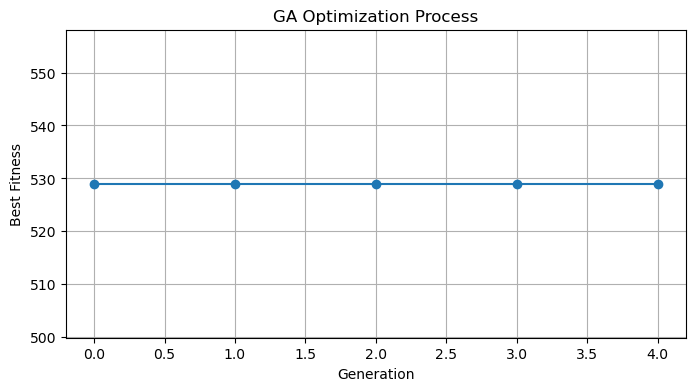

In [63]:
# =========================
# 11. 可视化
# =========================
plt.figure(figsize=(8, 4))
plt.plot(best_fitness_history, marker='o')
plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.title("GA Optimization Process")
plt.grid(True)
plt.show()

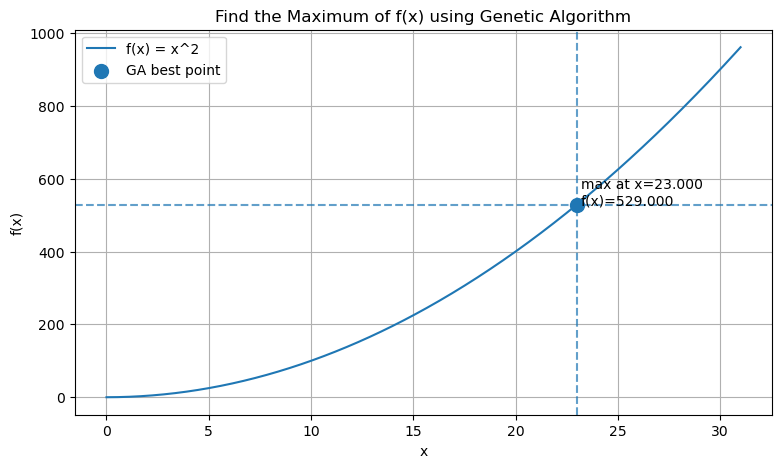

In [62]:
# =========================================================
# 10. 可视化 1：函数曲线 + 最大值位置
# =========================================================
best_y = best_fit

x_plot = np.linspace(LOW, HIGH, 500)
y_plot = objective_function(x_plot)

plt.figure(figsize=(9, 5))
plt.plot(x_plot, y_plot, label='f(x) = x^2')
plt.scatter(best_x, best_y, s=100, label='GA best point')
plt.axvline(best_x, linestyle='--', alpha=0.7)
plt.axhline(best_y, linestyle='--', alpha=0.7)

plt.text(best_x + 0.2, best_y,
         f"max at x={best_x:.3f}\nf(x)={best_y:.3f}",
         fontsize=10)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Find the Maximum of f(x) using Genetic Algorithm")
plt.legend()
plt.grid(True)
plt.show()